# 1. Loading the Data
In this section, I used the helper script to load all 27 subjects' edf & json files from the BIDS directory. The helper script provided some basic visualizations.

All data used in this project was sourced from https://openneuro.org/datasets/ds006142/versions/1.0.2/download.

In [9]:
import os
print(os.getcwd())

C:\Users\nehap2\OneDrive - University of North Carolina at Chapel Hill\SO\F25\NSCI 290\FINAL PROJECT


In [10]:
!pip install mne-bids


## 1.1 Reading EEG Signals

The provided helper script is courtesy of Fernandez (2025). Here we are importing the BIDS format dataset, looping over each of the 27 subjects, applying average reference, applying the standard BioSemi64 montage, and load events from the annotated dataset.

Extracting EDF parameters from D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\eeg\sub-001_task-MovieMemory_eeg.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading events from D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\eeg\sub-001_task-MovieMemory_events.tsv.
Reading 0 ... 7182335  =      0.000 ...  3507.000 secs...


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\3595653387.py:30: RuntimeWarning: Did not find any channels.tsv associated with sub-001_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\**\eeg\sub-001*channels.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=True)
C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\3595653387.py:30: RuntimeWarning: Did not find any eeg.json associated with sub-001_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\**\eeg\sub-001*eeg.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=True)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


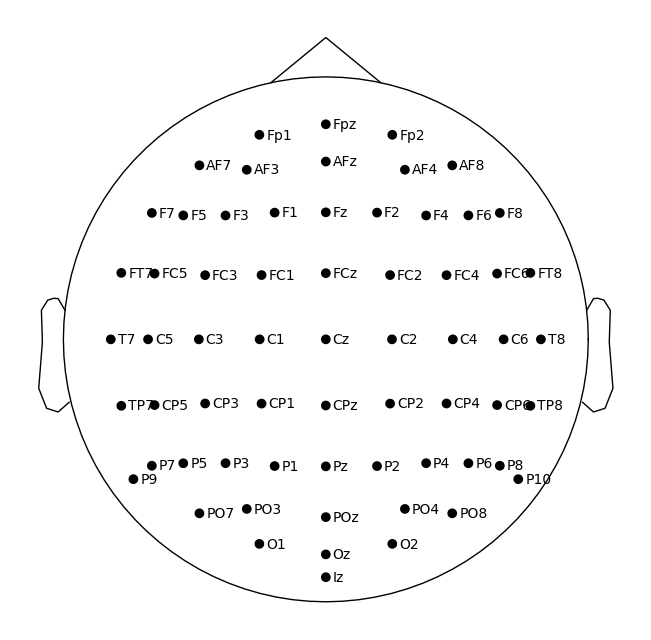

Used Annotations descriptions: [np.str_('endOfClip'), np.str_('firstRecognitionClick'), np.str_('recognitionClick'), np.str_('startOfNotRecognisedClip'), np.str_('startOfRecognisedClipFirstWatch'), np.str_('startOfRememberedClipFirstWatch'), np.str_('startOfSecondWatch'), np.str_('trialEnd'), np.str_('trialStart')]


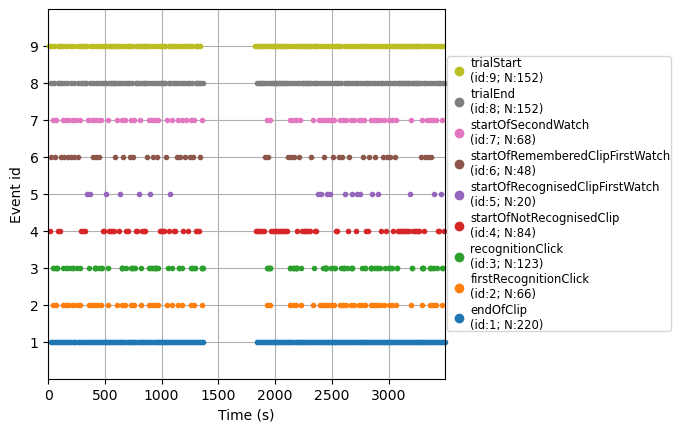

Not setting metadata
152 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 152 events and 2049 original time points (prior to decimation) ...
0 bad epochs dropped


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\3595653387.py:49: RuntimeWarning: The measurement information indicates a low-pass frequency of 1024.0 Hz. The decim=32 parameter will result in a sampling frequency of 64.0 Hz, which can cause aliasing artifacts.
  epochs = mne.Epochs(


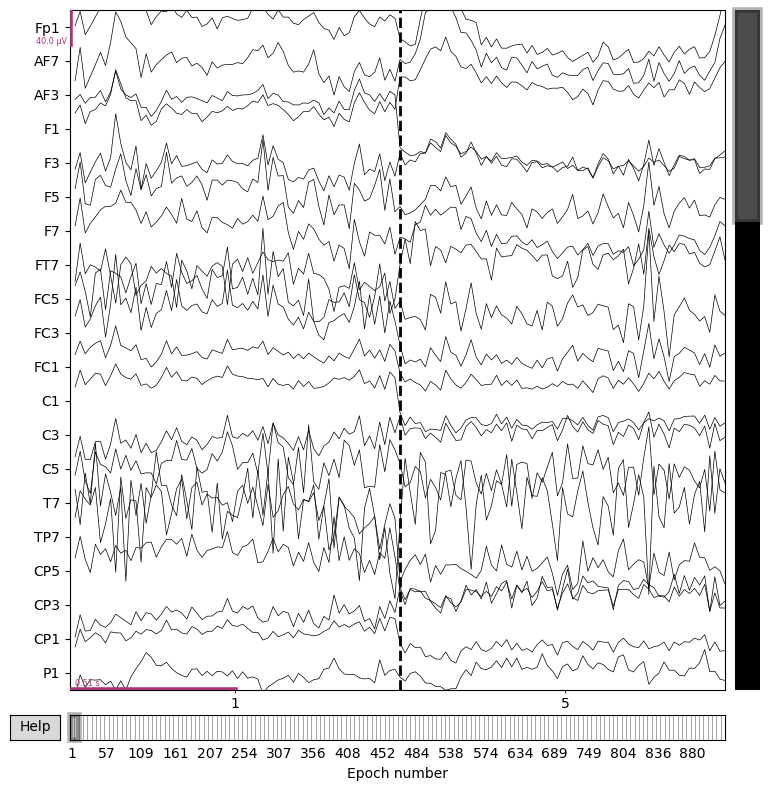

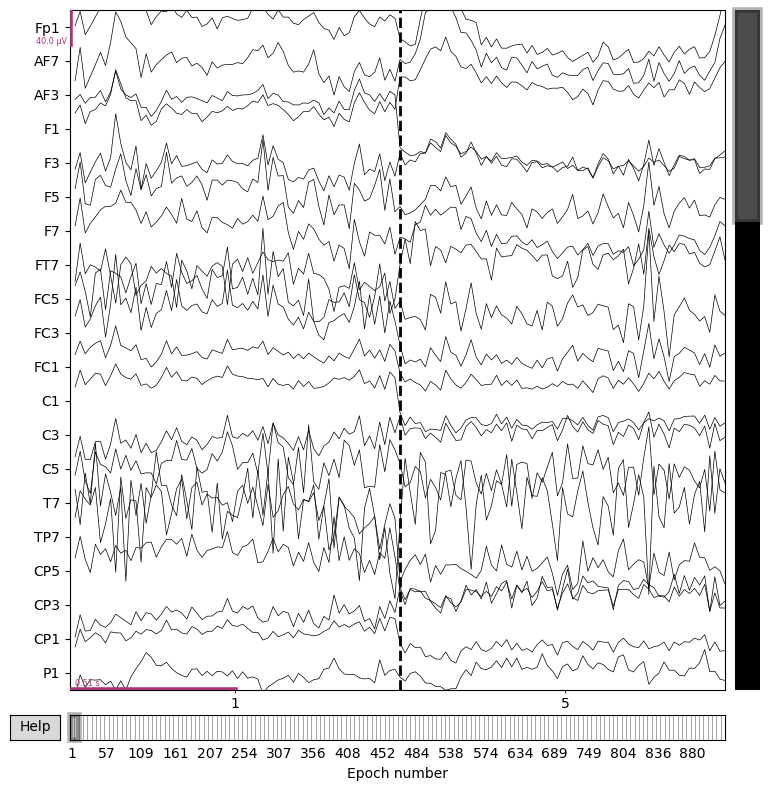

In [11]:
"""
An example of reading EEG signals using MNE package.
"""

import mne
from mne_bids import BIDSPath, read_raw_bids

event_id = {"startOfNotRecognisedClip": 1,
            "startOfRecognisedClipFirstWatch": 2,
            "startOfRememberedClipFirstWatch": 3,
            "startOfSecondWatch": 128,
            "endOfClip": 129,
            "recognitionClick": 160,
            "trialStart": 192,
            "trialEnd": 193,
            "firstRecognitionClick": 257
            } # Dictionary of events and corresponding triggers on the Status channel of the data


#%% read dataset from the BIDS format
participant = 1  # valid numbers: 1-27
bids_root = r"D:\\NP LAPTOP MEDIA\\N290 FINAL\\EEG Datasets"

subject = str(participant).zfill(3)
task = 'MovieMemory'
suffix = 'eeg'
datatype = 'eeg'

bids_path = BIDSPath(subject=subject, task=task, suffix=suffix, datatype=datatype, root=bids_root)
raw = read_raw_bids(bids_path=bids_path, verbose=True)
raw.load_data()

# reference EEG signals
raw.set_eeg_reference(ref_channels='average')  # Common average reference

# set montage
montage = mne.channels.make_standard_montage('biosemi64')
raw.set_montage(montage, on_missing='warn')

# plot electrode locations
raw.plot_sensors(show_names=True)

# plot all experiment events contained in this dataset
events, event_dict = mne.events_from_annotations(raw)
fig = mne.viz.plot_events(events, event_id=event_dict, sfreq=raw.info['sfreq'])

# extract image presentations
use_events = ["startOfNotRecognisedClip", "startOfRecognisedClipFirstWatch", "startOfRememberedClipFirstWatch"]
epochs = mne.Epochs(
    raw, events, event_id={e: event_dict[e] for e in use_events},
    tmin=0, tmax=1,
    baseline=None, decim=32, detrend=None, preload=True, verbose=True)

# plot epochs
epochs.plot(n_epochs=2)


# 2. Preprocessing & Epoching

After this step, the data should look smoother and more centered. We filtered the data with high-pass filtering and baseline correction to remove noise. Now, the data should represent true neuronal activity and have a better ratio of signal over artifacts.

## 2.1 Epoching and Event Extraction

This step of the pipeline epochs our channels into longer periods of time (1 second each), extracts events, and checks for missing events. Then, each of the epochs is added to epoch_dict, which is turned into a dataframe for easy viewing and analysis.

In [17]:
# This pipeline epochs our channels into shorter periods of time and checks for missing events.
# Then, each epoch is added to epoch_dict (which we will then turn into a df).

import mne
from mne_bids import BIDSPath, read_raw_bids
import gc

event_id = {
    "startOfNotRecognisedClip": 1,
    "startOfRecognisedClipFirstWatch": 2,
    "startOfRememberedClipFirstWatch": 3,
    "startOfSecondWatch": 128,
    "endOfClip": 129,
    "recognitionClick": 160,
    "trialStart": 192,
    "trialEnd": 193,
    "firstRecognitionClick": 257
}

bids_root = r"D:\\NP LAPTOP MEDIA\\N290 FINAL\\EEG Datasets"
task = "MovieMemory"
suffix = "eeg"
datatype = "eeg"

use_events = [
    "startOfNotRecognisedClip",
    "startOfRecognisedClipFirstWatch",
    "startOfRememberedClipFirstWatch"
]

epochs_dict = {}

for participant in range(1, 28):
    print(f"   Processing subject {participant:03d}")

    subject = f"{participant:03d}"
    raw = None
    epochs = None

    try:
        bids_path = BIDSPath(
            subject=subject,
            task=task,
            suffix=suffix,
            datatype=datatype,
            root=bids_root
        )

        raw = read_raw_bids(bids_path=bids_path, verbose=False)
        raw.load_data()
        raw.set_eeg_reference(ref_channels="average")

        montage = mne.channels.make_standard_montage("biosemi64")
        raw.set_montage(montage, on_missing="warn")

        # Extract events
        events, event_dict = mne.events_from_annotations(raw)

        # Filter events to only those actually present
        available_events = {e: event_dict[e] for e in use_events if e in event_dict}

        if len(available_events) == 0:
            print(f"No target events found for sub-{subject}. Skipping.")
            continue

        missing = set(use_events) - set(available_events.keys())
        if missing:
            print(f"Alert: Missing events for sub-{subject}: {missing}")

        # Create epochs only for available events
        epochs = mne.Epochs(
            raw,
            events,
            event_id=available_events,
            tmin=0,
            tmax=1,
            baseline=None,
            decim=32,
            preload=True,
            verbose=False
        )

        print(f"Created {len(epochs)} epochs for subject {subject}")
    
        epochs_dict[subject] = epochs

    except Exception as e:
        print(f"!!! Error processing subject {subject}: {e}")

    finally:
        if raw is not None:
            del raw
        if epochs is not None:
            del epochs

        gc.collect()
        print(f"Memory cleared for subject {subject}")
        # this step is critical

print("\nAll subjects processed!")

   Processing subject 001
Reading 0 ... 7182335  =      0.000 ...  3507.000 secs...


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:49: RuntimeWarning: Did not find any channels.tsv associated with sub-001_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\**\eeg\sub-001*channels.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:49: RuntimeWarning: Did not find any eeg.json associated with sub-001_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-001\**\eeg\sub-001*eeg.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('endOfClip'), np.str_('firstRecognitionClick'), np.str_('recognitionClick'), np.str_('startOfNotRecognisedClip'), np.str_('startOfRecognisedClipFirstWatch'), np.str_('startOfRememberedClipFirstWatch'), np.str_('startOfSecondWatch'), np.str_('trialEnd'), np.str_('trialStart')]


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:71: RuntimeWarning: The measurement information indicates a low-pass frequency of 1024.0 Hz. The decim=32 parameter will result in a sampling frequency of 64.0 Hz, which can cause aliasing artifacts.
  epochs = mne.Epochs(


Created 152 epochs for subject 001
Memory cleared for subject 001
   Processing subject 002
Reading 0 ... 4489215  =      0.000 ...  2192.000 secs...


...

Memory cleared for subject 026
   Processing subject 027
Reading 0 ... 7305215  =      0.000 ...  3567.000 secs...


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:49: RuntimeWarning: Did not find any channels.tsv associated with sub-027_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-027\**\eeg\sub-027*channels.tsv"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)
C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:49: RuntimeWarning: Did not find any eeg.json associated with sub-027_task-MovieMemory.

The search_str was "D:\NP LAPTOP MEDIA\N290 FINAL\EEG Datasets\sub-027\**\eeg\sub-027*eeg.json"
  raw = read_raw_bids(bids_path=bids_path, verbose=False)


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('endOfClip'), np.str_('firstRecognitionClick'), np.str_('recognitionClick'), np.str_('startOfNotRecognisedClip'), np.str_('startOfRecognisedClipFirstWatch'), np.str_('startOfRememberedClipFirstWatch'), np.str_('startOfSecondWatch'), np.str_('trialEnd'), np.str_('trialStart')]


C:\Users\nehap2\AppData\Local\Temp\ipykernel_23956\1916200835.py:71: RuntimeWarning: The measurement information indicates a low-pass frequency of 1024.0 Hz. The decim=32 parameter will result in a sampling frequency of 64.0 Hz, which can cause aliasing artifacts.
  epochs = mne.Epochs(


Created 176 epochs for subject 027
Memory cleared for subject 027

All subjects processed!


### 2.1.1 Storing the Data in a DataFrame

In [19]:
import pandas as pd
import numpy as np

# We'll create a list to store each subject's data as a dict
data_list = []

for subject, epochs in epochs_dict.items():
    # Get the data: shape is (n_epochs, n_channels, n_times)
    epoch_data = epochs.get_data()
    
    # Option 1: average across time and epochs to get one value per channel
    # Resulting shape: (n_channels,)
    mean_signal_per_channel = epoch_data.mean(axis=(0, 2))
    
    # Create a dictionary for this subject
    subject_dict = {ch: mean_signal_per_channel[i] for i, ch in enumerate(epochs.ch_names)}
    subject_dict["subject"] = subject
    
    data_list.append(subject_dict)

# Convert to DataFrame
df = pd.DataFrame(data_list)

# Optional: set 'subject' as index
df.set_index("subject", inplace=True)

print(df.head())


              Fp1       AF7       AF3        F1        F3            F5  \
subject                                                                   
001     -0.000025  0.000051 -0.000008 -0.000126  0.000042 -4.668338e-05   
002      0.000262 -0.000046 -0.000041 -0.000208 -0.000104 -6.882509e-07   
003      0.000052 -0.000007 -0.000044 -0.000048 -0.000051 -8.372319e-06   
004      0.000012 -0.000028 -0.000043 -0.000051  0.000050  1.334870e-04   
005     -0.000130 -0.000047 -0.000035 -0.000004 -0.000018 -3.946881e-05   

               F7       FT7       FC5       FC3  ...       CP4       CP2  \
subject                                          ...                       
001     -0.000027  0.000041 -0.000030 -0.000005  ...  0.000108 -0.000040   
002      0.000011  0.000159  0.000023 -0.000019  ... -0.000058 -0.000193   
003      0.000152 -0.000033 -0.000098  0.000006  ...  0.000077 -0.000011   
004      0.000032  0.000011  0.000145  0.000072  ... -0.000180  0.000007   
005      0.000087 

In [23]:
participants_df = pd.read_csv("participants.tsv", sep='\t')
participants_df.rename(columns={'participant_id': 'subject'}, inplace=True)
participants_df['subject'] = participants_df['subject'].astype(str).str.zfill(3)
print(participants_df.head())

# Remove "sub-" prefix
participants_df['subject'] = participants_df['subject'].str.replace("sub-", "", regex=False)

# Make sure they are strings with leading zeros
participants_df['subject'] = participants_df['subject'].astype(str).str.zfill(3)

# Merging
df = df.drop(columns=['age', 'sex', 'hand'], errors='ignore')  # remove if they exist
df = df.merge(participants_df, on='subject', how='left')

print(df.head)

print(df[['subject', 'age', 'sex', 'hand']])


   subject  age sex hand
0  sub-001   25   M    R
1  sub-002   24   F    R
2  sub-003   47   F    R
3  sub-004   26   F    R
4  sub-005   29   M    R
<bound method NDFrame.head of    subject       Fp1       AF7       AF3        F1        F3            F5  \
0      001 -0.000025  0.000051 -0.000008 -0.000126  0.000042 -4.668338e-05   
1      002  0.000262 -0.000046 -0.000041 -0.000208 -0.000104 -6.882509e-07   
2      003  0.000052 -0.000007 -0.000044 -0.000048 -0.000051 -8.372319e-06   
3      004  0.000012 -0.000028 -0.000043 -0.000051  0.000050  1.334870e-04   
4      005 -0.000130 -0.000047 -0.000035 -0.000004 -0.000018 -3.946881e-05   
5      006  0.000007 -0.000017 -0.000168 -0.000070 -0.000089  7.399589e-06   
6      007 -0.000111 -0.000125  0.000065  0.000083  0.000004 -1.656278e-04   
7      008 -0.000126  0.000045  0.000005  0.000079  0.000041 -1.378199e-05   
8      009 -0.000136  0.000036 -0.000007 -0.000087 -0.000075  1.449148e-05   
9      010 -0.006030  0.000381 -0.002947

## 2.2 Preprocessing
Extracting signal columns, performing baseline correction by subtracting the mean of each channel, adding a high-pass filter, and storing the filtered data in a DataFrame.

In [24]:
from scipy.signal import butter, filtfilt

# Extract signal columns
signal_cols = [col for col in df.columns if col not in participants_df and df[col].dtype in [np.float64, np.int64]]
signals = df[signal_cols].astype(float)


# 2. Preprocessing / Cleaning

# Baseline correction: subtract mean of each channel
signals_bc = signals.sub(signals.mean(axis=1), axis=0)

# Optional high-pass filter (2.05 Hz)
b, a = butter(1, 1/(0.5*2048), btype='high')  # assume 1 kHz sampling

# Apply filtfilt row-wise and store as DataFrame with same index & columns
signals_filt = pd.DataFrame(
    [filtfilt(b, a, signals_bc.loc[ch].values, padlen=3) for ch in signals_bc.index],
    index=signals_bc.index,
    columns=signals_bc.columns
)

# Replace eeg_data signals with filtered data
df[signal_cols] = signals_filt

print("Filtered eeg_data shape:", df.shape)
df.head()

Filtered eeg_data shape: (26, 68)


,subject,Fp1,AF7,AF3,F1,F3,F5,F7,FT7,FC5,...,P4,P6,P8,P10,PO8,PO4,O2,age,sex,hand
0,001,-0.000788,-0.000716,-0.000779,-0.000901,-0.000737,-0.000831,-0.000816,-0.000752,-0.000828,...,-0.001178,-0.001040,-0.001037,-0.001027,-0.001080,-0.001100,-0.000513,25,M,R
1,002,0.000111,-0.000194,-0.000185,-0.000349,-0.000241,-0.000134,-0.000119,0.000033,-0.000100,...,0.000033,0.000166,0.000209,0.000208,0.000433,0.000354,0.000104,24,F,R
2,003,-0.000142,-0.000202,-0.000239,-0.000244,-0.000247,-0.000204,-0.000044,-0.000230,-0.000295,...,-0.000271,-0.000226,-0.000361,-0.000212,-0.000206,-0.000136,-0.000106,47,F,R
3,004,-0.000203,-0.000244,-0.000259,-0.000268,-0.000169,-0.000086,-0.000188,-0.000210,-0.000077,...,-0.000187,-0.000341,-0.000279,-0.000528,-0.000230,-0.000227,-0.000264,26,F,R
4,005,-0.000055,0.000026,0.000037,0.000067,0.000052,0.000029,0.000154,0.000080,0.000054,...,0.000066,0.000007,0.000042,-0.000026,0.000018,0.000028,-0.000013,29,M,R


This dataframe illustrates our filtered data, which includes epoch indices, event types, different bands (delta, theta, alpha, beta), and the key event label associated with each epoch.

In [26]:
epochs_dict.keys()

dict_keys(['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027'])

# 3. Extract Features

## 3.1 Extracting Bandpower Features (Welch's PSD)

In [28]:
import mne
import numpy as np

all_subjects_psd_data = []
freqs = None

for subject_id, epochs_data in epochs_dict.items():
    print(f"Processing data for subject: {subject_id}")

 
    try:
        spectrum = epochs_data.compute_psd(method='multitaper')

        psd_data = spectrum.get_data()

        # Store the frequencies the first time through
        if freqs is None:
            freqs = spectrum.freqs

        all_subjects_psd_data.append(psd_data)
        
    except Exception as e:
        print(f"Error processing subject {subject_id}: {e}")

print(f"Collected PSD data from {len(all_subjects_psd_data)} subjects.")


combined_psd_data = np.concatenate(all_subjects_psd_data, axis=0)

grand_average_psd = np.mean(combined_psd_data, axis=0)

print(f"Grand average PSD shape: {grand_average_psd.shape}")


Processing data for subject: 001
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 002
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 003
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 004
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 005
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 006
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 007
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 008
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 009
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 010
    Using multitaper spectrum estimation with 7 DPSS windows
Processing data for subject: 011
    Using multitaper spectr

This tells us that our dataset has 64 channels and 33 frequency bins.

In [32]:
bands = {"delta": (0.5, 4), "theta": (4, 8),
         "alpha": (8, 12), "beta": (12, 30)}


## 3.2 Computing Connectivity Features (Pearson's r)
Computing delta, theta, alpha, beta power across epochs.

### 3.2.1 Per Epoch
This step in feature engineering enhances the features available to us and provides a straightforward, interpretable index of channel-to-channel relationships. This data will be used to improve the RandomForest classifier in step 3.

In [30]:
mne_connectivity.spectral_connectivity_epochs()

NameError: name 'mne_connectivity' is not defined

In [51]:
import numpy as np
import pandas as pd

all_features = []

for i in range(len(epochs)):
    data = epochs[i].get_data().squeeze()
    corr_matrix = np.corrcoef(data)
    corr_features = corr_matrix[np.triu_indices(data.shape[0], k=1)]
    
    # Create a dict for this epoch including event_id
    row = {"event_id": epochs.events[i, 2]}  # <-- add event ID
    # Add all connectivity features
    for j, val in enumerate(corr_features):
        row[f"conn_{j}"] = val
    
    all_features.append(row)

# Convert to DataFrame
df_conn = pd.DataFrame(all_features)
print(df_conn.shape)
print(df_conn.head())


(152, 2017)
   event_id    conn_0    conn_1    conn_2    conn_3    conn_4    conn_5  \
0         4  0.876362  0.833409  0.606935  0.651346  0.503019  0.646298   
1         6  0.983185  0.960940  0.817161  0.786266  0.635828  0.851008   
2         6  0.906112  0.829939  0.645437  0.703868  0.602635  0.715332   
3         4  0.980776  0.951100  0.543309  0.590364  0.614926  0.840805   
4         4  0.860087  0.799275  0.486608  0.576501  0.430687  0.591409   

     conn_6    conn_7    conn_8  ...  conn_2006  conn_2007  conn_2008  \
0  0.110531  0.321960  0.462090  ...   0.622142   0.719619   0.645374   
1  0.274183  0.208137  0.213249  ...   0.705206   0.657299   0.585940   
2  0.540158  0.309023  0.463275  ...   0.634970   0.644451   0.592241   
3  0.583108  0.403558  0.245091  ...   0.819706   0.878436   0.784128   
4  0.436785  0.298489  0.251021  ...   0.540242   0.659721   0.464752   

   conn_2009  conn_2010  conn_2011  conn_2012  conn_2013  conn_2014  conn_2015  
0   0.542538   0.

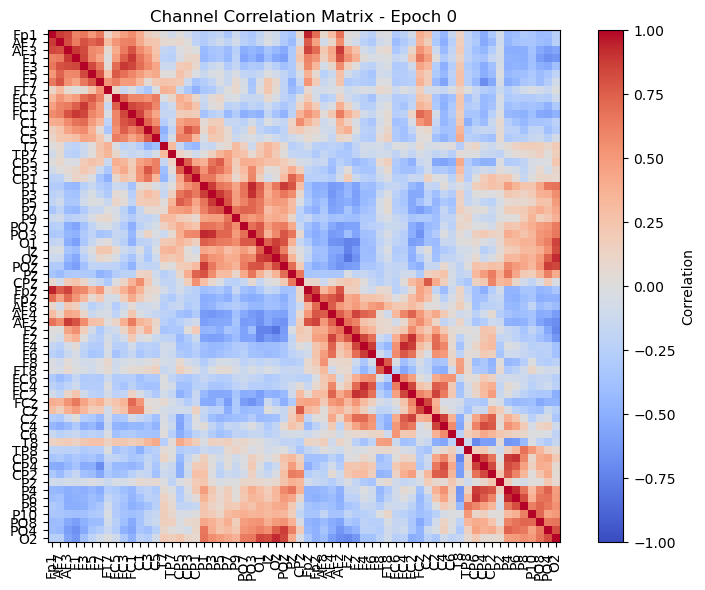

(152, 64, 64)
Number of correlation features per epoch: 2016


In [52]:
# correlation matrix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pick an epoch index
epoch_idx = 0

# Extract data: shape = n_channels x n_times
epoch_data = epochs[epoch_idx].get_data().squeeze()

# Compute correlation matrix across channels
corr_matrix = np.corrcoef(epoch_data)

# Convert to DataFrame for nicer labeling
corr_df = pd.DataFrame(corr_matrix, index=epochs.ch_names, columns=epochs.ch_names)

# Plot
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(ticks=np.arange(len(epochs.ch_names)), labels=epochs.ch_names, rotation=90)
plt.yticks(ticks=np.arange(len(epochs.ch_names)), labels=epochs.ch_names)
plt.title(f'Channel Correlation Matrix - Epoch {epoch_idx}')
plt.tight_layout()
plt.show()

epoch_corrs = []

for i in range(len(epochs)):
    data = epochs[i].get_data().squeeze()
    corr_matrix = np.corrcoef(data)
    epoch_corrs.append(corr_matrix)

# Convert to array: n_epochs x n_channels x n_channels
epoch_corrs = np.array(epoch_corrs)
print(epoch_corrs.shape)  # (n_epochs, n_channels, n_channels)


# Epoch 0
n_ch = len(epochs.ch_names)
triu_idx = np.triu_indices(n_ch, k=1) 
corr_features = epoch_corrs[0][triu_idx] 

print("Number of correlation features per epoch:", len(corr_features))


# 4. Feature Engineering & Assembly
Now that we have structured data and connectivity metrics, we will add more information with demographics about each participant and concatenate this across all participants.

## 4.1 DataFrame of Connectivity Features to Prepare for ML

In [53]:
import pandas as pd
import numpy as np


all_rows = []

for subj, epochs_subj in epochs_dict.items():
    n_ch = len(epochs_subj.ch_names)
    triu_idx = np.triu_indices(n_ch, k=1)
    
    for i in range(len(epochs_subj)):
        # Get epoch data
        data = epochs_subj[i].get_data().squeeze()  # n_ch x n_times
        
        corr_matrix = np.corrcoef(data)
        corr_features = corr_matrix[triu_idx]
        
        row = {f"{epochs_subj.ch_names[a]}_{epochs_subj.ch_names[b]}": val 
               for (a,b), val in zip(zip(*triu_idx), corr_features)}
        row['subject'] = subj
        row['epoch_index'] = i
        row['event_label'] = epochs_subj.events[i,2]
        
        # Add demographics into the df
        subj_info = participants_df[participants_df['subject']==subj].iloc[0]
        row['age'] = subj_info['age']
        row['sex'] = subj_info['sex']
        row['hand'] = subj_info['hand']
        
        all_rows.append(row)

# Combine all epochs into a single dataframe
df_ml = pd.DataFrame(all_rows)

print("ML-ready dataframe shape:", df_ml.shape)
print(df_ml.head())



ML-ready dataframe shape: (3815, 2022)
    Fp1_AF7   Fp1_AF3    Fp1_F1    Fp1_F3    Fp1_F5    Fp1_F7   Fp1_FT7  \
0  0.876362  0.833409  0.606935  0.651346  0.503019  0.646298  0.110531   
1  0.983185  0.960940  0.817161  0.786266  0.635828  0.851008  0.274183   
2  0.906112  0.829939  0.645437  0.703868  0.602635  0.715332  0.540158   
3  0.980776  0.951100  0.543309  0.590364  0.614926  0.840805  0.583108   
4  0.860087  0.799275  0.486608  0.576501  0.430687  0.591409  0.436785   

    Fp1_FC5   Fp1_FC3   Fp1_FC1  ...    P10_O2   PO8_PO4    PO8_O2    PO4_O2  \
0  0.321960  0.462090  0.558185  ...  0.492199  0.641717  0.666858  0.806832   
1  0.208137  0.213249  0.080517  ...  0.575914  0.833017  0.906874  0.866697   
2  0.309023  0.463275  0.321408  ...  0.796292  0.848404  0.919004  0.828132   
3  0.403558  0.245091  0.036876  ...  0.803078  0.794002  0.850623  0.848353   
4  0.298489  0.251021  0.539791  ...  0.378210  0.735057  0.879250  0.869851   

   subject  epoch_index  even

In [54]:
len(df_ml)  # should be 3815

3815

In [69]:
event_map = {4: "NotRecognised", 5: "RecognisedFirstWatch", 6: "RememberedFirstWatch"}
df_conn['label'] = df_conn['event_id'].map(event_map)
df_conn = df_conn.dropna(subset=['label']).reset_index(drop=True)


## 4.2 Extract Features for Each Subject

In [70]:
subject = "001"  # example
epochs = epochs_dict[subject]  # get the epochs for this subject

print("Sampling frequency:", epochs.info['sfreq'])

fmax_allowed = epochs.info['sfreq'] / 2


Sampling frequency: 64.0


In [71]:
# Defining Frequency bands
bands = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta":  (12, 30), 
    # gamma is not included because it exceeds the limit of 16 Hz
}

def extract_bandpower_features(epochs, bands):
    """
    Compute bandpower features per epoch using Welch PSD.
    Returns a list of dictionaries, one per epoch.
    """
    fmax_allowed = epochs.info['sfreq'] / 2  

    safe_bands = {}
    for band, (f_low, f_high) in bands.items():
        f_high_safe = min(f_high, fmax_allowed)
        if f_low < f_high_safe:
            safe_bands[band] = (f_low, f_high_safe)

    # Compute PSD
    psd_obj = epochs.compute_psd(
        fmin=1,
        fmax=fmax_allowed,
        method="welch",
        n_fft= epochs.get_data().shape[2]
,
        verbose=False
    )
    psd = psd_obj.get_data()  
    freqs = psd_obj.freqs

    # Extract average bandpower per epoch
    features = []
    for i, epoch_psd in enumerate(psd):
        row = {}
        for band, (f_low, f_high) in safe_bands.items():
            idx = np.logical_and(freqs >= f_low, freqs <= f_high)
            row[band] = epoch_psd[:, idx].mean()  # average across channels
        features.append(row)

    return features

# Loop through and combine all subjects in the df
all_rows = []

for participant in range(1, 28):
    subject = f"{participant:03d}"
    print(f"Processing subject {subject} ...")

    epochs = None
    try:
        epochs = epochs_dict[subject]
        features = extract_bandpower_features(epochs, bands)
        for i, feat_row in enumerate(features):
            row = {
                "subject": subject,
                "epoch_index": i,
                "event_type": epochs.events[i, 2]  # integer trigger
            }
            row.update(feat_row)
            all_rows.append(row)
    except Exception as e:
        print(f"Error processing this subject {subject}: {e}")

    finally:
        if epochs is not None:
            del epochs
        gc.collect()

df = pd.DataFrame(all_rows)
print("\nCombined dataframe shape:", df.shape)
print(df.head())

df.to_csv("combined_features.csv", index=False)
df.to_parquet("combined_features.parquet", index=False)

print("Done: Combined features into a dataframe")


Processing subject 001 ...
Processing subject 002 ...
Processing subject 003 ...
Processing subject 004 ...
Processing subject 005 ...
Processing subject 006 ...
Processing subject 007 ...
Processing subject 008 ...
Processing subject 009 ...
Processing subject 010 ...
Processing subject 011 ...
Processing subject 012 ...
Processing subject 013 ...
Processing subject 014 ...
Processing subject 015 ...
Error processing this subject 015: '015'
Processing subject 016 ...
Processing subject 017 ...
Processing subject 018 ...
Processing subject 019 ...
Processing subject 020 ...
Processing subject 021 ...
Processing subject 022 ...
Processing subject 023 ...
Processing subject 024 ...
Processing subject 025 ...
Processing subject 026 ...
Processing subject 027 ...

Combined dataframe shape: (3815, 7)
  subject  epoch_index  event_type         delta         theta         alpha  \
0     001            0           4  1.379897e-11  8.293860e-12  1.147945e-11   
1     001            1           

In [72]:
event_map = {
    4: "NotRecognised",
    5: "RecognisedFirstWatch",
    6: "RememberedFirstWatch"
}

df_conn['label'] = df_conn['event_id'].map(event_map)
df_conn = df_conn.dropna(subset=['label']).reset_index(drop=True)


# 5. Scaling and PCA

In [75]:
df_encoded = pd.get_dummies(df_ml, columns=['sex', 'hand'], drop_first=False)
print(df_encoded.columns)


print(df_encoded[['subject','sex_M', 'sex_F', 'hand_R', 'hand_L']].head())

# IDK if I did this right


Index(['Fp1_AF7', 'Fp1_AF3', 'Fp1_F1', 'Fp1_F3', 'Fp1_F5', 'Fp1_F7', 'Fp1_FT7',
       'Fp1_FC5', 'Fp1_FC3', 'Fp1_FC1',
       ...
       'PO8_O2', 'PO4_O2', 'subject', 'epoch_index', 'event_label', 'age',
       'sex_F', 'sex_M', 'hand_L', 'hand_R'],
      dtype='object', length=2024)
  subject  sex_M  sex_F  hand_R  hand_L
0     001   True  False    True   False
1     001   True  False    True   False
2     001   True  False    True   False
3     001   True  False    True   False
4     001   True  False    True   False


In [87]:
# Example DataFrame: df_encoded includes connectivity + bandpower + demographics
numeric_cols = df_encoded.select_dtypes(include=np.number).columns.tolist()
non_numeric_cols = df_encoded.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns:", numeric_cols[:10], "…")
print("Non-numeric columns:", non_numeric_cols)



Numeric columns: ['Fp1_AF7', 'Fp1_AF3', 'Fp1_F1', 'Fp1_F3', 'Fp1_F5', 'Fp1_F7', 'Fp1_FT7', 'Fp1_FC5', 'Fp1_FC3', 'Fp1_FC1'] …
Non-numeric columns: ['subject', 'sex_F', 'sex_M', 'hand_L', 'hand_R']


In [88]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_numeric = df_encoded[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original numeric shape:", X_numeric.shape)
print("PCA-transformed shape:", X_pca.shape)


Original numeric shape: (3815, 2019)
PCA-transformed shape: (3815, 488)


In [124]:
pca.explained_variance_ratio_.sum()


np.float64(0.950068580695712)

# 6. Training the Classifier/Model

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)


# 7. Testing & Evaluating the Model

## 7.1 Evaluating with a Confusion Matrix

In [154]:
subjects = df["subject"].values
print(len(subjects))

non_numeric_cols = X.select_dtypes(include=['object'])
print(non_numeric_cols.columns)
cols_to_drop = non_numeric_cols.columns
X = X.drop(columns=cols_to_drop)


from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

logo = LeaveOneGroupOut()

loso_accuracies = []
all_true = []
all_pred = []

for train_idx, test_idx in logo.split(X, y, groups=subjects):

    X_train = X.iloc[train_idx]
    X_test  = X.iloc[test_idx]
    y_train = y[train_idx]
    y_test  = y[test_idx]

    clf = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    loso_accuracies.append(accuracy_score(y_test, y_pred))
    all_true.extend(y_test)
    all_pred.extend(y_pred)

print("Mean LOSO accuracy:", np.mean(loso_accuracies))


3815
Index(['sex', 'hand'], dtype='object')
Mean LOSO accuracy: 0.5345671973602024


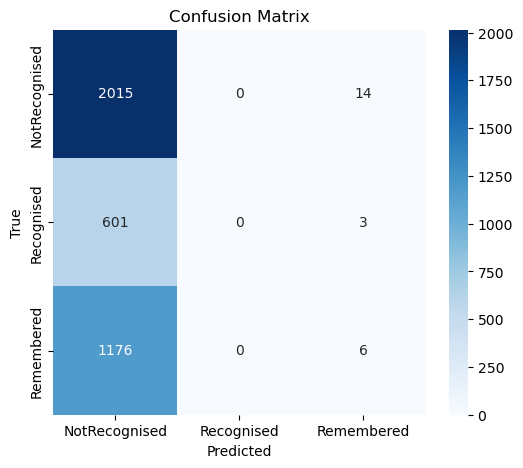

In [167]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Replace y_test and y_pred with your variables
cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NotRecognised", "Recognised", "Remembered"],
            yticklabels=["NotRecognised", "Recognised", "Remembered"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


## 7.2 Classwise Comparisons

In [114]:
# Select numeric columns for both train and test
numeric_cols = X_train.select_dtypes(include=np.number).columns

X_train_numeric = X_train[numeric_cols]
X_test_numeric  = X_test[numeric_cols]

# Fit classifier
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train_numeric, y_train)

# Predict probabilities
y_score = clf.predict_proba(X_test_numeric)
y_true = y_test


In [116]:
from sklearn.metrics import roc_auc_score

# y_true: true labels
y_true = y_test  

# y_score: predicted probabilities for each class
y_score = clf.predict_proba(X_test_numeric)  

# Compute multi-class ROC-AUC
roc_auc = roc_auc_score(y_true, y_score, average=None, multi_class='ovr')
print("ROC-AUC per class:", roc_auc)


ROC-AUC per class: [0.52809874 0.47916667 0.63882212]


In [119]:
logo = LeaveOneGroupOut()
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

cv_scores = cross_val_score(clf, X_scaled, y, groups=groups, cv=logo)

print("LOSO CV accuracy per subject:", cv_scores)
print("Mean LOSO CV accuracy:", cv_scores.mean())

LOSO CV accuracy per subject: [0.86842105 0.83185841 0.82191781 0.59541985 0.74193548 0.71428571
 0.72316384 0.83333333 0.66285714 0.75       0.68275862 0.35151515
 0.60126582 0.78676471 0.90298507 0.74025974 0.7375     0.44615385
 0.83707865 0.8125     0.7195122  0.51219512 0.62666667 0.60240964
 0.85714286 0.70454545]
Mean LOSO CV accuracy: 0.7101710068843805


# 7. Statistical Analyses

In [156]:
print(df_ml['event_label'].value_counts())


event_label
4    2029
6    1182
5     604
Name: count, dtype: int64


In [158]:
from scipy.stats import shapiro

features = ["delta", "theta", "alpha", "beta"]

for f in features:
    stat, p = shapiro(df[f])
    print(f"{f}: p = {p:.2e}")


delta: p = 5.97e-88
theta: p = 1.29e-84
alpha: p = 2.49e-84
beta: p = 2.25e-85


In [162]:
from scipy.stats import levene

features = ["delta", "theta", "alpha", "beta"]


for f in features:
    groups = [df[df_ml['event_label']==lab][f] for lab in df_ml['event_label'].unique()]
    stat, p = levene(*groups)
    print(f"{f}: p = {p:.2e}")


delta: p = 1.39e-02
theta: p = 1.43e-04
alpha: p = 2.57e-03
beta: p = 3.79e-02


In [164]:
from scipy.stats import kruskal

features = ["delta", "theta", "alpha", "beta"]


for f in features:
    groups = [df[df_ml['event_label']==lab][f] for lab in df_ml['event_label'].unique()]
    stat, p = kruskal(*groups)
    print(f"{f}: Kruskal-Wallis p = {p:.4f}")


delta: Kruskal-Wallis p = 0.0000
theta: Kruskal-Wallis p = 0.0395
alpha: Kruskal-Wallis p = 0.0024
beta: Kruskal-Wallis p = 0.0002


In [165]:
from scipy.stats import f_oneway

bands = ["delta", "theta", "alpha", "beta"]

for band in bands:
    groups = [df.loc[df_ml['event_label'] == lab, band].values for lab in df_ml['event_label'].unique()]
    f_stat, p_val = f_oneway(*groups)
    print(f"{band}: F = {f_stat:.3f}, p = {p_val:.4f}")

NameError: name 'df_features' is not defined

# 8. Visualizations: Heatmap, Confusion Matrix, Feature Importance

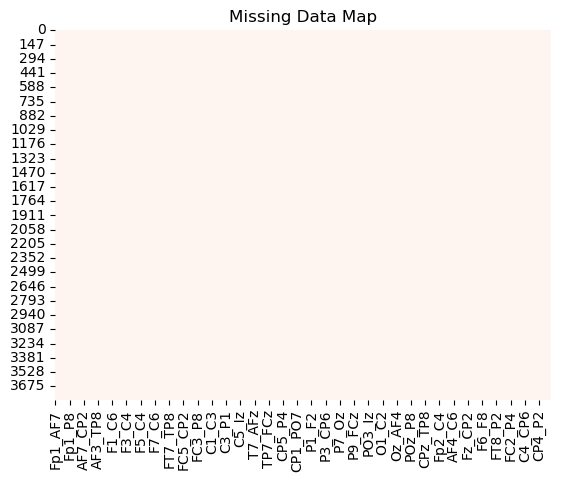

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df_ml.isna(), cmap="Reds", cbar=False)
plt.title("Missing Data Map")
plt.show()

#### Visualization: Epoch-Level Plotting

This intermediate visualization shows us a single epoch to ensure it is within the expected scale of axes. This code was edited with the help of ChatGPT. A connectivity matrix was also visualized with df_conn.

I also want to compute the explained variance to understand how much variance was retained. # I estimate it to be about 80-85%.

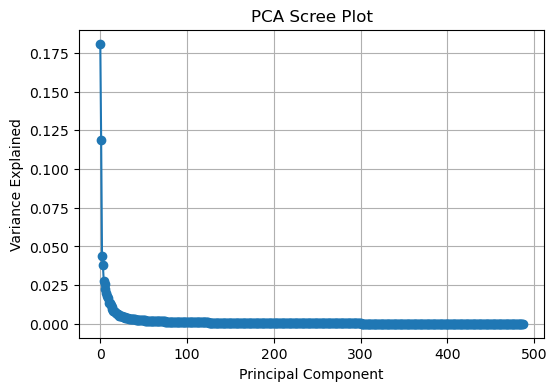

In [132]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(pca.explained_variance_ratio_, marker='o')
plt.title("PCA Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.grid(True)
plt.show()


In [131]:
print(df_ml['event_label'].value_counts())


event_label
4    2029
6    1182
5     604
Name: count, dtype: int64


In [136]:
from scipy.stats import ttest_1samp
import numpy as np

loso_accuracies = [0.86842105, 0.83185841, 0.82191781, 0.59541985, 0.74193548, 0.71428571,
 0.72316384, 0.83333333, 0.66285714, 0.75,       0.68275862, 0.35151515,
 0.60126582, 0.78676471, 0.90298507, 0.74025974, 0.7375,     0.44615385,
 0.83707865, 0.8125,     0.7195122,  0.51219512, 0.62666667, 0.60240964,
 0.85714286, 0.70454545]

chance = 1/3  # three classes
t_stat, p_val = ttest_1samp(loso_accuracies, chance)

print("T-test: Is LOSO accuracy > chance?")
print("t =", t_stat)
print("p =", p_val)


T-test: Is LOSO accuracy > chance?
t = 14.363301490380257
p = 1.3915128105010045e-13


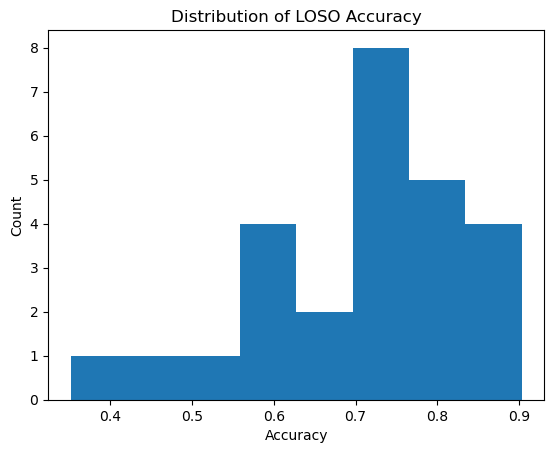

In [138]:
plt.hist(loso_accuracies, bins=8)
plt.title("Distribution of LOSO Accuracy")
plt.xlabel("Accuracy")
plt.ylabel("Count")
plt.show()


In [ ]:
print(df.columns.tolist())


In [126]:
from itertools import permutations

def perm_anova(df_band, col, df_labels, group_col, n_perm=5000):
    groups = [df_band.loc[df_labels[group_col] == g, col].values for g in df_labels[group_col].unique()]
    k = len(groups)
    n = len(df_band)
    grand_mean = df_band[col].mean()
    ss_between = sum(len(g)*(g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(((g - g.mean())**2).sum() for g in groups)
    F_obs = (ss_between/(k-1)) / (ss_within/(n-k))

    p = 0
    for _ in range(n_perm):
        shuffled = df_band[col].sample(frac=1, replace=False).values
        df_shuffled = df_band.copy()
        df_shuffled[col] = shuffled
        groups_s = [df_shuffled.loc[df_labels[group_col] == g, col].values for g in df_labels[group_col].unique()]
        ss_between_s = sum(len(g)*(g.mean() - grand_mean)**2 for g in groups_s)
        ss_within_s = sum(((g - g.mean())**2).sum() for g in groups_s)
        F_perm = (ss_between_s/(k-1)) / (ss_within_s/(n-k))
        if F_perm >= F_obs:
            p += 1

    return F_obs, p / n_perm

for band in ["delta", "theta", "alpha", "beta"]:
    F, p = perm_anova(df, band, df_ml, "event_label")
    print(f"{band}: F={F:.3f}, p={p:.4g}")

KeyError: 'event_label'

In [1]:
# Next steps: pairwise between 3 event labels/groups only for the beta values
# See: Library to do HSD test or other post hoc pairwise tests

NameError: name 'df_ml' is not defined